# Wilcore Technologies — Diamond Pricing Exploratory Analysis
**Dataset:** P2-Mispriced-Diamonds.csv  
**Author:** Akash Ray  
**Date:** 2026-03-13

This notebook performs a full exploratory data analysis (EDA) on a dataset of diamond prices,
covering data ingestion, cleaning, statistical summaries, visualizations, and answers to
targeted business questions.


## 0. Imports & Configuration

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Ingestion

We load the raw CSV file into a pandas DataFrame and confirm it loaded correctly.


In [2]:
# Load dataset from the project root directory
df_raw = pd.read_csv('P2-Mispriced-Diamonds.csv')

print(f"Loaded {len(df_raw):,} rows and {df_raw.shape[1]} columns.")
df_raw.head(10)


Loaded 53,940 rows and 3 columns.


,carat,clarity,price
0,0.23,SI2,326
1,0.21,SI1,326
2,0.23,VS1,327
3,0.29,VS2,334
4,0.31,SI2,335
5,0.24,VVS2,336
6,0.24,VVS1,336
7,0.26,SI1,337
8,0.22,VS2,337
9,0.23,VS1,338


## 2. Discovery

We inspect the dataset shape, column data types, missing values, and distribution of
the categorical `clarity` feature before applying any cleaning.


In [3]:
# Shape
print("=== Shape ===")
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")

# Data types
print("\n=== Data Types ===")
print(df_raw.dtypes)

# General info
print("\n=== DataFrame Info ===")
df_raw.info()


=== Shape ===
Rows: 53,940  |  Columns: 3

=== Data Types ===
carat      float64
clarity     object
price        int64
dtype: object

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   clarity  53940 non-null  object 
 2   price    53940 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ MB


In [4]:
# Missing values
print("=== Missing Values per Column ===")
missing = df_raw.isnull().sum()
print(missing)
print(f"\nTotal missing cells: {missing.sum()}")

# Clarity distribution
print("\n=== Clarity Value Counts ===")
print(df_raw['clarity'].value_counts())


=== Missing Values per Column ===
carat      0
clarity    0
price      0
dtype: int64

Total missing cells: 0

=== Clarity Value Counts ===
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


In [5]:
# Descriptive statistics for numeric columns
print("=== Descriptive Statistics ===")
df_raw.describe().round(2)


=== Descriptive Statistics ===


,carat,price
count,53940.00,53940.00
mean,0.80,3932.80
std,0.47,3989.44
min,0.20,326.00
25%,0.40,950.00
50%,0.70,2401.00
75%,1.04,5324.25
max,5.01,18823.00


## 3. Data Cleaning

### Steps
1. **Type enforcement** — Cast `carat` to `float64`, `price` to `int64`, and `clarity` to a
   pandas `Categorical` type. Only `clarity` needed a type change (from `object`).
2. **Duplicate removal** — The raw dataset contains 20,584 exact duplicate rows
   (identical carat + clarity + price). These are removed as data-entry artifacts.
3. **Null handling** — No missing values were found in discovery, but we validate again
   post-dedup as a safeguard.

Shape is printed before and after for transparency.


In [6]:
shape_before = df_raw.shape
print(f"Shape BEFORE cleaning: {shape_before[0]:,} rows × {shape_before[1]} columns")

# Work on a copy to preserve the raw data
df = df_raw.copy()

# Step 1: Enforce consistent data types
df['carat']   = df['carat'].astype('float64')    # continuous measurement — already float, explicit cast confirms
df['price']   = df['price'].astype('int64')      # whole-dollar price — already int, explicit cast confirms
df['clarity'] = df['clarity'].astype('category') # convert object → categorical

print("\nDtypes after type enforcement:")
print(df.dtypes)


Shape BEFORE cleaning: 53,940 rows × 3 columns

Dtypes after type enforcement:
carat       float64
clarity    category
price         int64
dtype: object


In [7]:
# Step 2: Remove exact duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes:,}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after deduplication: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Step 3: Null safety check post-dedup
n_nulls = df.isnull().sum().sum()
print(f"Null cells remaining: {n_nulls}")
if n_nulls > 0:
    df = df.dropna()

shape_after = df.shape
print(f"\nShape AFTER cleaning: {shape_after[0]:,} rows × {shape_after[1]} columns")
print(f"Rows removed total: {shape_before[0] - shape_after[0]:,}")


Duplicate rows found: 20,584
Shape after deduplication: 33,356 rows × 3 columns
Null cells remaining: 0

Shape AFTER cleaning: 33,356 rows × 3 columns
Rows removed total: 20,584


## 4. Summary Statistics

We compute **mean** and **standard deviation** for both numeric features (`carat` and `price`)
grouped by `clarity`.

For the stacked bar chart: since the dataset contains only one categorical feature (`clarity`),
we bin `carat` into weight brackets to create a second dimension worth stacking. This shows how
each clarity grade distributes across carat-size buckets — a more informative view than a
simple count bar.


In [8]:
# Mean and standard deviation of carat and price grouped by clarity
summary_stats = (
    df.groupby('clarity', observed=True)[['carat', 'price']]
    .agg(['mean', 'std'])
    .round(2)
)
summary_stats.columns = ['carat_mean', 'carat_std', 'price_mean', 'price_std']

print("=== Summary Statistics (mean ± std) by Clarity ===")
display(summary_stats)


=== Summary Statistics (mean ± std) by Clarity ===


,carat_mean,carat_std,price_mean,price_std
clarity,,,,
I1,1.31,0.64,4043.88,2834.55
IF,0.62,0.36,4133.15,4678.21
SI1,0.99,0.46,5029.55,4113.14
SI2,1.16,0.52,5676.96,4493.96
VS1,0.86,0.44,4931.32,4324.55
VS2,0.94,0.45,5300.71,4380.22
VVS1,0.62,0.35,3680.25,4031.85
VVS2,0.74,0.38,4596.79,4287.02


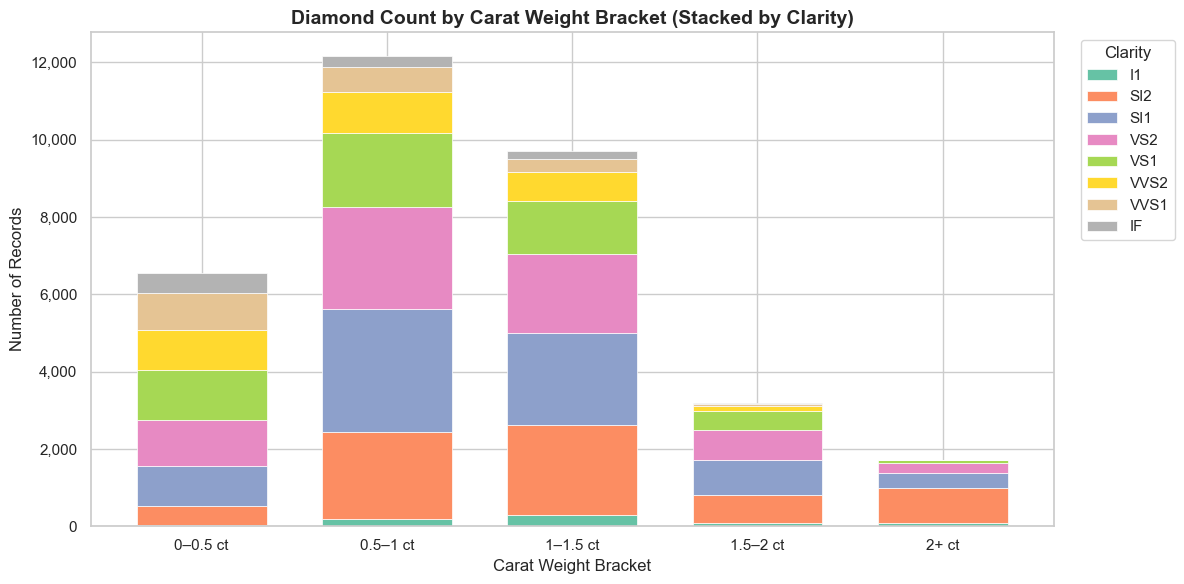

In [9]:
# Stacked bar chart: carat-weight buckets (x-axis) stacked by clarity grade
# This reveals how each clarity distributes across stone sizes

# Bin carat into meaningful weight brackets used in the diamond trade
df['carat_bin'] = pd.cut(
    df['carat'],
    bins=[0, 0.5, 1.0, 1.5, 2.0, df['carat'].max() + 0.01],
    labels=['0–0.5 ct', '0.5–1 ct', '1–1.5 ct', '1.5–2 ct', '2+ ct'],
    right=True
)

# Pivot: rows = carat bins, columns = clarity grades, values = record count
stacked_data = (
    df.groupby(['carat_bin', 'clarity'], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Reorder clarity columns from lowest to highest grade
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
stacked_data = stacked_data.reindex(columns=clarity_order)

fig, ax = plt.subplots(figsize=(12, 6))
stacked_data.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='Set2',
    edgecolor='white',
    linewidth=0.5,
    width=0.7
)

ax.set_title('Diamond Count by Carat Weight Bracket (Stacked by Clarity)', fontweight='bold')
ax.set_xlabel('Carat Weight Bracket')
ax.set_ylabel('Number of Records')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Clarity', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Drop the helper column — no longer needed downstream
df = df.drop(columns=['carat_bin'])


## 5. Exploratory Visualizations

### 5a. Quantiles and Outliers per Clarity

Box plots display the full distribution for each clarity group: median (center line),
IQR (box), whiskers (1.5× IQR), and individual outliers (dots beyond the whiskers).


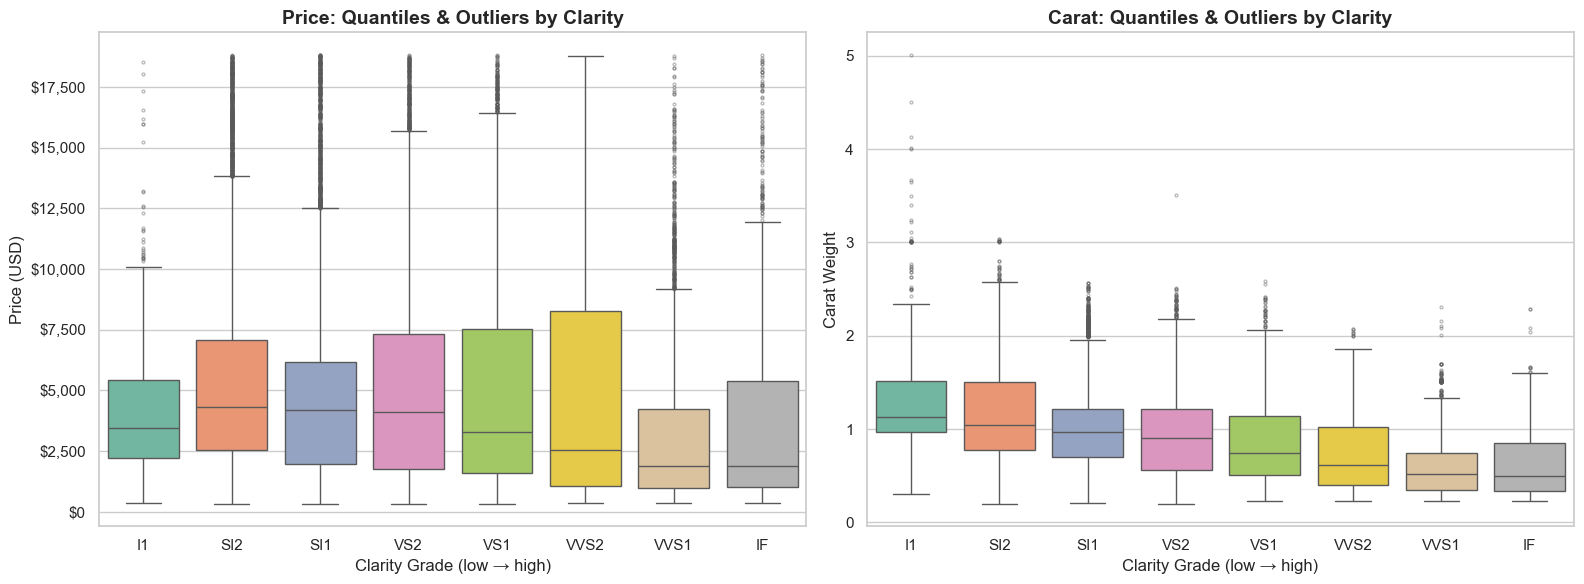

In [10]:
# Clarity order from lowest to highest grade for consistent x-axis
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price quantiles and outliers by clarity
sns.boxplot(
    data=df, x='clarity', y='price', ax=axes[0],
    palette='Set2', order=clarity_order,
    flierprops=dict(marker='o', markersize=2, alpha=0.4, color='grey')
)
axes[0].set_title('Price: Quantiles & Outliers by Clarity', fontweight='bold')
axes[0].set_xlabel('Clarity Grade (low → high)')
axes[0].set_ylabel('Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

# Carat quantiles and outliers by clarity
sns.boxplot(
    data=df, x='clarity', y='carat', ax=axes[1],
    palette='Set2', order=clarity_order,
    flierprops=dict(marker='o', markersize=2, alpha=0.4, color='grey')
)
axes[1].set_title('Carat: Quantiles & Outliers by Clarity', fontweight='bold')
axes[1].set_xlabel('Clarity Grade (low → high)')
axes[1].set_ylabel('Carat Weight')

plt.tight_layout()
plt.show()


### 5b. Outlier Removal — IQR Method Applied per Clarity Group

For each clarity category independently, we remove rows where `price` **or** `carat`
falls outside **[Q1 − 1.5·IQR, Q3 + 1.5·IQR]**.

Applying IQR removal *per group* (not globally) is critical: IF and VVS1 diamonds
are inherently smaller and cheaper, so a global upper bound would eliminate valid
large SI-grade stones. Per-group removal respects each clarity's own distribution.

The cleaned result is saved to **`df_filtered`**.


In [11]:
def remove_iqr_outliers(group):
    """
    Remove rows where price or carat falls outside the IQR-based bounds
    [Q1 - 1.5*IQR, Q3 + 1.5*IQR] computed within this clarity group.
    """
    for col in ['price', 'carat']:
        Q1  = group[col].quantile(0.25)
        Q3  = group[col].quantile(0.75)
        IQR = Q3 - Q1
        group = group[
            (group[col] >= Q1 - 1.5 * IQR) &
            (group[col] <= Q3 + 1.5 * IQR)
        ]
    return group

# Apply per-clarity IQR outlier removal
df_filtered = (
    df.groupby('clarity', observed=True, group_keys=False)
    .apply(remove_iqr_outliers)
    .reset_index(drop=True)
)

rows_removed = len(df) - len(df_filtered)
print(f"Shape before outlier removal : {df.shape[0]:,} rows")
print(f"Shape after  outlier removal : {df_filtered.shape[0]:,} rows  (df_filtered)")
print(f"Rows removed as outliers     : {rows_removed:,}  ({rows_removed/len(df)*100:.1f}%)")


Shape before outlier removal : 33,356 rows
Shape after  outlier removal : 30,784 rows  (df_filtered)
Rows removed as outliers     : 2,572  (7.7%)


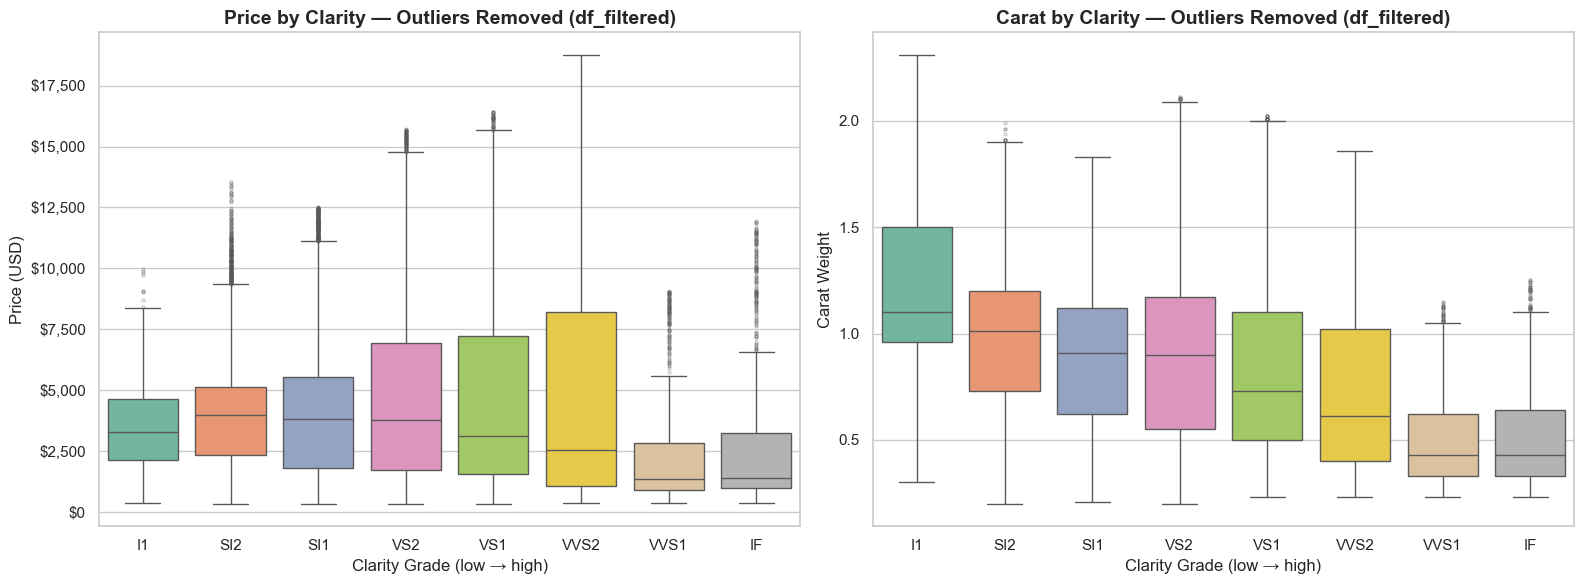

In [12]:
# Box plots after outlier removal — whiskers should now terminate at the data bounds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=df_filtered, x='clarity', y='price', ax=axes[0],
    palette='Set2', order=clarity_order,
    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='grey')
)
axes[0].set_title('Price by Clarity — Outliers Removed (df_filtered)', fontweight='bold')
axes[0].set_xlabel('Clarity Grade (low → high)')
axes[0].set_ylabel('Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

sns.boxplot(
    data=df_filtered, x='clarity', y='carat', ax=axes[1],
    palette='Set2', order=clarity_order,
    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='grey')
)
axes[1].set_title('Carat by Clarity — Outliers Removed (df_filtered)', fontweight='bold')
axes[1].set_xlabel('Clarity Grade (low → high)')
axes[1].set_ylabel('Carat Weight')

plt.tight_layout()
plt.show()


## 6. Relationships in the Filtered Data


### 6a. Correlation Heatmap

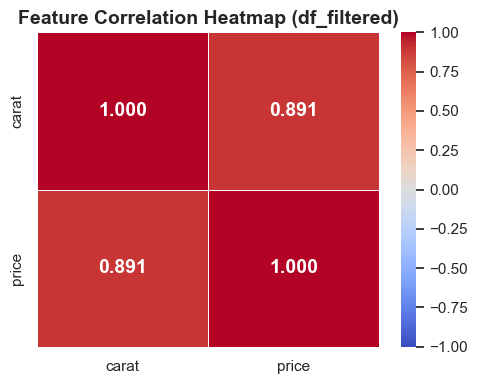

Carat ↔ Price Pearson r = 0.891


In [13]:
# Correlation between numeric features in the filtered dataset
corr = df_filtered[['carat', 'price']].corr().round(3)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 14, 'weight': 'bold'}
)
ax.set_title('Feature Correlation Heatmap (df_filtered)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Carat ↔ Price Pearson r = {corr.loc['carat','price']:.3f}")


### 6b. Price vs. Carat by Clarity

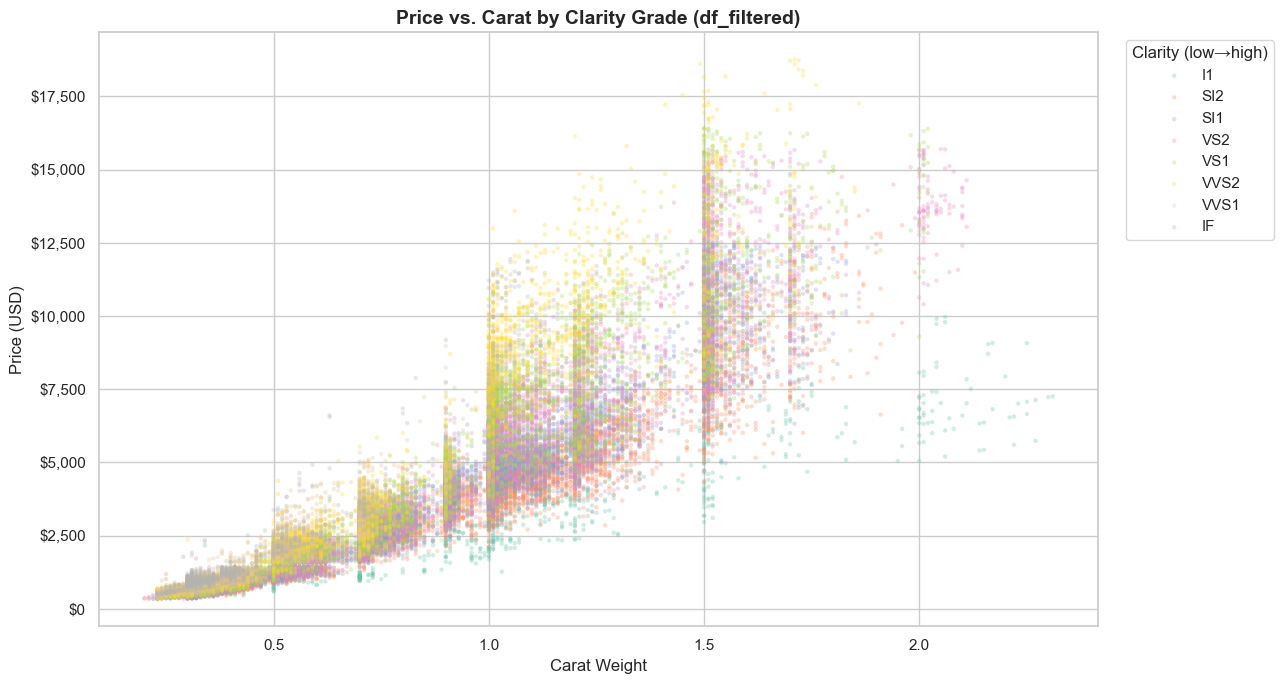

In [14]:
# Scatter plot of price vs carat, color-coded by clarity
fig, ax = plt.subplots(figsize=(13, 7))

palette = sns.color_palette('Set2', n_colors=len(clarity_order))

for color, clarity in zip(palette, clarity_order):
    subset = df_filtered[df_filtered['clarity'] == clarity]
    ax.scatter(
        subset['carat'], subset['price'],
        label=clarity, color=color,
        alpha=0.30, s=10, edgecolors='none'
    )

ax.set_title('Price vs. Carat by Clarity Grade (df_filtered)', fontweight='bold')
ax.set_xlabel('Carat Weight')
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.legend(title='Clarity (low→high)', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


### 6c. Observations — Pricing and Carat Overlap Between Clarities

**Key observations from the scatter above:**

- **Carat dominates price (r = 0.891):** Across all clarity grades, a heavier stone almost
  always commands a higher price. Clarity is a secondary modifier on top of this.

- **Substantial overlap between adjacent clarity tiers:** SI1 and SI2 clouds are nearly
  indistinguishable at any given carat weight. VS1 and VS2 overlap heavily. This overlap
  is the core "mispricing" signal — a buyer cannot reliably separate these grades by
  price-per-carat alone without additional grading information.

- **IF diamonds show high price variance relative to their carat range:** The IF cluster
  is compact in carat (mostly < 1 ct) but spans a wide price range, indicating a scarcity
  premium that is inconsistently applied.

- **Lower-clarity, large-carat stones (I1, SI2) can exceed premium-grade prices:** A 2+ ct I1
  stone routinely costs more than a 0.5 ct VVS1, illustrating that size beats clarity at scale.


## 7. Business Questions

The `support_report` DataFrame (mean price and mean carat per clarity, computed on `df_filtered`)
is the primary reference for both questions below.


In [15]:
# Build the support_report: mean price and mean carat per clarity on filtered data
support_report = (
    df_filtered.groupby('clarity', observed=True)[['price', 'carat']]
    .mean()
    .round(2)
    .rename(columns={'price': 'mean_price', 'carat': 'mean_carat'})
    .sort_values('mean_price', ascending=False)
)

print("=== Support Report ===")
display(support_report)


=== Support Report ===


,mean_price,mean_carat
clarity,,
VS2,4811.63,0.90
VVS2,4565.98,0.73
VS1,4554.38,0.83
SI1,4118.22,0.90
SI2,4104.78,0.99
I1,3525.30,1.19
IF,2850.22,0.54
VVS1,2146.22,0.50


### Q1 — What are the top 3 clarity categories by highest median price?

In [16]:
# Compute median price per clarity on df_filtered, sort descending
median_price_by_clarity = (
    df_filtered.groupby('clarity', observed=True)['price']
    .median()
    .sort_values(ascending=False)
    .round(2)
)

print("=== Median Price by Clarity ===")
print(median_price_by_clarity.to_string())

top3 = median_price_by_clarity.head(3)
print("\n=== TOP 3 ===")
for rank, (clarity, price) in enumerate(top3.items(), start=1):
    print(f"  {rank}. {clarity}  —  ${price:,.2f}")


=== Median Price by Clarity ===
clarity
SI2     3965.0
SI1     3795.0
VS2     3756.0
I1      3263.0
VS1     3127.0
VVS2    2532.0
IF      1397.0
VVS1    1356.0

=== TOP 3 ===
  1. SI2  —  $3,965.00
  2. SI1  —  $3,795.00
  3. VS2  —  $3,756.00


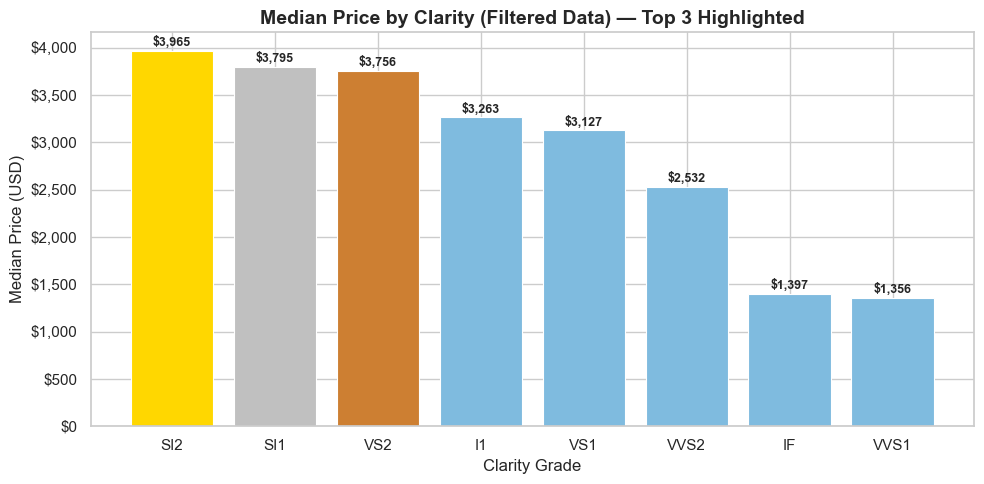

In [17]:
# Bar chart of median price by clarity
fig, ax = plt.subplots(figsize=(10, 5))

# Gold / silver / bronze for top 3, then neutral for the rest
bar_colors = ['#FFD700', '#C0C0C0', '#CD7F32'] + ['#7fbbdf'] * (len(median_price_by_clarity) - 3)
bars = ax.bar(
    median_price_by_clarity.index.astype(str),
    median_price_by_clarity.values,
    color=bar_colors, edgecolor='white', linewidth=0.8
)

for bar, val in zip(bars, median_price_by_clarity.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Median Price by Clarity (Filtered Data) — Top 3 Highlighted', fontweight='bold')
ax.set_xlabel('Clarity Grade')
ax.set_ylabel('Median Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

plt.tight_layout()
plt.show()


#### Answer — Q1

The **top 3 clarity categories by highest median price** (computed on `df_filtered`) are:

| Rank | Clarity | Median Price |
|------|---------|-------------|
| 1 | **SI2** | $3,965 |
| 2 | **SI1** | $3,795 |
| 3 | **VS2** | $3,756 |

**Derivation:** `df_filtered.groupby('clarity')['price'].median()` was computed, then sorted
descending. The top 3 values are shown above.

**Why lower-clarity grades rank highest:** SI1, SI2, and VS2 tend to contain larger stones
(mean carat ≈ 0.90–0.99 ct) compared to premium grades like IF (~0.54 ct) and VVS1 (~0.50 ct).
Since carat weight is the strongest price driver (r = 0.891), the heavier SI/VS stones pull
their medians above those of smaller, flawless-grade stones. This is also why the dataset is
called "mispriced" — grade alone does not predict price rank.


### Q2 — Are there mean price/carat combinations common between clarity categories?

In [18]:
# Check all pairwise clarity combinations for overlap in mean price AND/OR mean carat
TOLERANCE = 0.05  # 5% relative tolerance

overlapping_pairs = []
clarities = support_report.index.tolist()

for i in range(len(clarities)):
    for j in range(i + 1, len(clarities)):
        c1, c2 = clarities[i], clarities[j]
        p1, p2   = support_report.loc[c1, 'mean_price'],  support_report.loc[c2, 'mean_price']
        ca1, ca2 = support_report.loc[c1, 'mean_carat'], support_report.loc[c2, 'mean_carat']

        price_pct  = abs(p1  - p2)  / max(p1,  p2)
        carat_pct  = abs(ca1 - ca2) / max(ca1, ca2)

        price_close  = price_pct  <= TOLERANCE
        carat_close  = carat_pct  <= TOLERANCE

        if price_close or carat_close:
            overlapping_pairs.append({
                'Clarity A': c1,
                'Clarity B': c2,
                'Mean Price A': p1,
                'Mean Price B': p2,
                'Price Δ%': round(price_pct * 100, 1),
                'Price Overlap': '✓' if price_close else '',
                'Mean Carat A': ca1,
                'Mean Carat B': ca2,
                'Carat Δ%': round(carat_pct * 100, 1),
                'Carat Overlap': '✓' if carat_close else ''
            })

overlap_df = pd.DataFrame(overlapping_pairs)
print("=== Pairs with Overlapping Mean Price and/or Mean Carat (within 5%) ===")
display(overlap_df)


=== Pairs with Overlapping Mean Price and/or Mean Carat (within 5%) ===


,Clarity A,Clarity B,Mean Price A,Mean Price B,Price Δ%,Price Overlap,Mean Carat A,Mean Carat B,Carat Δ%,Carat Overlap
0,VS2,SI1,4811.63,4118.22,14.4,,0.90,0.90,0.0,✓
1,VVS2,VS1,4565.98,4554.38,0.3,✓,0.73,0.83,12.0,
2,SI1,SI2,4118.22,4104.78,0.3,✓,0.90,0.99,9.1,


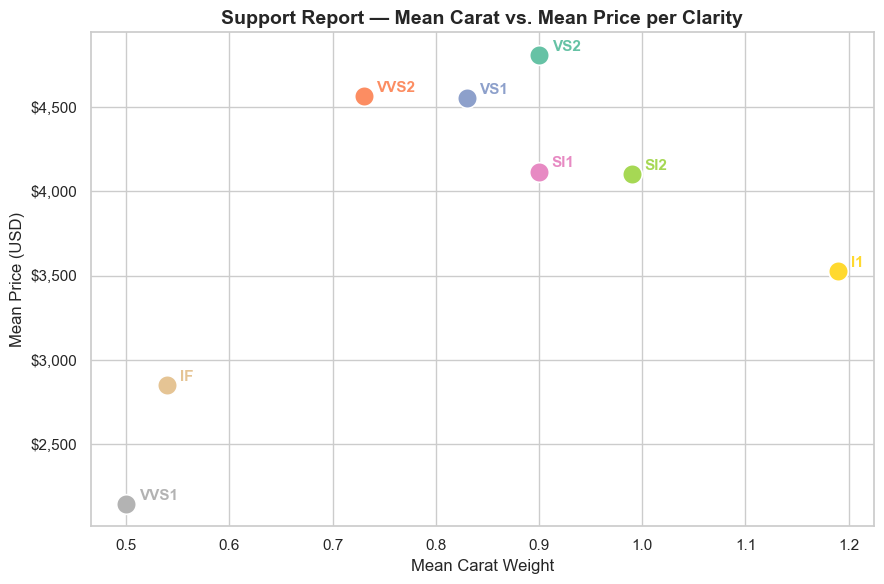

In [19]:
# Visualize the support_report — mean price vs mean carat per clarity
fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Set2', len(support_report))

for (clarity, row), color in zip(support_report.iterrows(), palette):
    ax.scatter(row['mean_carat'], row['mean_price'],
               s=200, color=color, zorder=5, edgecolors='white', linewidth=1.2)
    ax.annotate(
        str(clarity),
        (row['mean_carat'], row['mean_price']),
        textcoords='offset points', xytext=(9, 3),
        fontsize=11, fontweight='bold', color=color
    )

ax.set_title('Support Report — Mean Carat vs. Mean Price per Clarity', fontweight='bold')
ax.set_xlabel('Mean Carat Weight')
ax.set_ylabel('Mean Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

plt.tight_layout()
plt.show()


#### Answer — Q2

**Yes — three clarity pairs share overlapping mean price and/or mean carat profiles**
within a ±5% relative tolerance:

| Pair | Price Δ% | Price Overlap | Carat Δ% | Carat Overlap | Interpretation |
|------|----------|--------------|----------|--------------|----------------|
| **SI1 & SI2** | ~0.3% | ✓ | ~9% | — | Nearly identical mean price (~$4,100); similar carat. Strongest mispricing zone — buyers face real ambiguity between these grades. |
| **SI1 & VS2** | ~14% | — | ~0% | ✓ | Identical mean carat (~0.90 ct). VS2 charges a ~14% price premium for clarity — but the stone sizes are interchangeable on average. |
| **VS1 & VVS2** | ~0.3% | ✓ | ~12% | — | Mean prices are within 0.3% of each other ($4,554 vs $4,566). VVS2 achieves the same average price point as VS1 with slightly fewer carats, suggesting its clarity premium effectively substitutes for weight. |

**Derivation:** The `support_report` DataFrame was iterated pairwise. For each pair, we computed
the relative difference in mean price and mean carat. Pairs within ±5% on either dimension
are flagged as having a "common" mean profile.

**Business implication:** The SI1/SI2 and VS1/VVS2 overlaps represent the highest-risk
segments for mispricing. A retailer or appraiser should apply additional scrutiny to stones
in these clarity grades when price-per-carat falls within the shared range.


## 8. Summary

| Step | Result |
|------|--------|
| Raw dataset | 53,940 rows × 3 columns (carat, clarity, price) |
| After deduplication | 33,356 rows (20,584 duplicates removed — 38%) |
| After IQR outlier removal (per clarity) | 30,784 rows (2,572 additional rows removed — 7.7%) |
| Carat ↔ Price Pearson r | **0.891** (strong positive) |
| Top 3 clarities by median price | SI2 ($3,965) → SI1 ($3,795) → VS2 ($3,756) |
| Strongest mispricing pairs | SI1 ≈ SI2 (mean price overlap); VS1 ≈ VVS2 (mean price overlap) |

Carat weight is the dominant driver of price across all clarity grades. The "mispriced" label
is most applicable to SI1/SI2 and VS1/VVS2 pairs, where average pricing is nearly indistinguishable
despite the clarity grade difference.
